## Topic Modeling: Latent Dirichlet Allocation with sklearn

### Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [4]:
%matplotlib inline

from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

import pyLDAvis
from pyLDAvis import prepare

from wordcloud import WordCloud
from termcolor import colored

# sklearn for feature extraction & modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
import joblib

In [5]:
sns.set_style("white")
plt.rcParams["figure.figsize"] = (14.0, 8.7)

In [6]:
pyLDAvis.enable_notebook()

In [7]:
# change to your data path if necessary
DATA_DIR = Path("../data")
data_path = DATA_DIR / "bbc"

In [8]:
results_path = Path("results")
model_path = Path("results", "bbc")
if not model_path.exists():
    model_path.mkdir(exist_ok=True, parents=True)

## Load BBC data

Using the BBC data as before, we use [sklearn.decomposition.LatentDirichletAllocation](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html) to train an LDA model with five topics.

In [9]:
files = sorted(list(data_path.glob("**/*.txt")))
doc_list = []
for i, file in enumerate(files):
    with open(str(file), encoding="latin1") as f:
        topic = file.parts[-2]
        lines = f.readlines()
        heading = lines[0].strip()
        body = " ".join([l.strip() for l in lines[1:]])
        doc_list.append([topic.capitalize(), heading, body])

### Convert to DataFrame

In [10]:
docs = pd.DataFrame(doc_list, columns=["topic", "heading", "article"])
docs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   topic    2225 non-null   object
 1   heading  2225 non-null   object
 2   article  2225 non-null   object
dtypes: object(3)
memory usage: 52.3+ KB


## Create Train & Test Sets

In [11]:
train_docs, test_docs = train_test_split(
    docs, stratify=docs.topic, test_size=125, random_state=42
)

In [12]:
train_docs.shape, test_docs.shape

((2100, 3), (125, 3))

In [13]:
pd.Series(test_docs.topic).value_counts()

topic
Sport            29
Business         29
Politics         23
Tech             22
Entertainment    22
Name: count, dtype: int64

### Vectorize train & test sets

In [15]:
# experiments with different settings results yields the following hyperparameters (see issue 50)
vectorizer = TfidfVectorizer(max_df=0.11, min_df=0.026, stop_words="english")

train_dtm = vectorizer.fit_transform(train_docs.article)
words = vectorizer.get_feature_names_out()
train_dtm

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 113356 stored elements and shape (2100, 1097)>

In [16]:
test_dtm = vectorizer.transform(test_docs.article)
test_dtm

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6779 stored elements and shape (125, 1097)>

## LDA with sklearn

In [17]:
n_components = 5
topic_labels = [f"Topic {i}" for i in range(1, n_components + 1)]

In [18]:
lda_base = LatentDirichletAllocation(
    n_components=n_components, n_jobs=-1, learning_method="batch", max_iter=10
)
lda_base.fit(train_dtm)

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


### Persist model

The model tracks the in-sample perplexity during training and stops iterating once this measure stops improving. We can persist and load the result as usual with sklearn objects:

In [19]:
joblib.dump(lda_base, model_path / "lda_10_iter.pkl")

['results\\bbc\\lda_10_iter.pkl']

In [20]:
lda_base = joblib.load(model_path / "lda_10_iter.pkl")
lda_base

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


## Explore topics & word distributions

In [21]:
# pseudo counts
topics_count = lda_base.components_
print(topics_count.shape)
topics_count[:5]

(5, 1097)


array([[8.07431327, 8.67013192, 8.66331589, ..., 6.95378737, 6.34394401,
        5.51684238],
       [3.71144467, 1.09067193, 3.09657424, ..., 0.58471218, 2.32650952,
        0.86309352],
       [0.20620907, 0.20100923, 0.52225502, ..., 0.20352318, 1.04032006,
        0.59299666],
       [1.15421837, 4.40236077, 3.11238502, ..., 0.22036936, 4.57999458,
        4.73692812],
       [1.39148173, 2.71092982, 4.10824258, ..., 2.39360326, 1.61279492,
        4.49023412]])

In [22]:
topics_prob = topics_count / topics_count.sum(axis=1).reshape(-1, 1)
topics = pd.DataFrame(topics_prob.T, index=words, columns=topic_labels)
topics.head()

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
100,0.001286,0.001548,0.000463,0.000788,0.000453
11,0.001381,0.000455,0.000451,0.003007,0.000884
12,0.001380,0.001291,0.001173,0.002126,0.001339
13,0.000676,0.000549,0.001927,0.001796,0.001270
14,0.000925,0.000675,0.000460,0.001339,0.001022


In [23]:
# all words have positive probability for all topics
topics[topics.gt(0).all(1)].shape[0] == topics.shape[0]

True

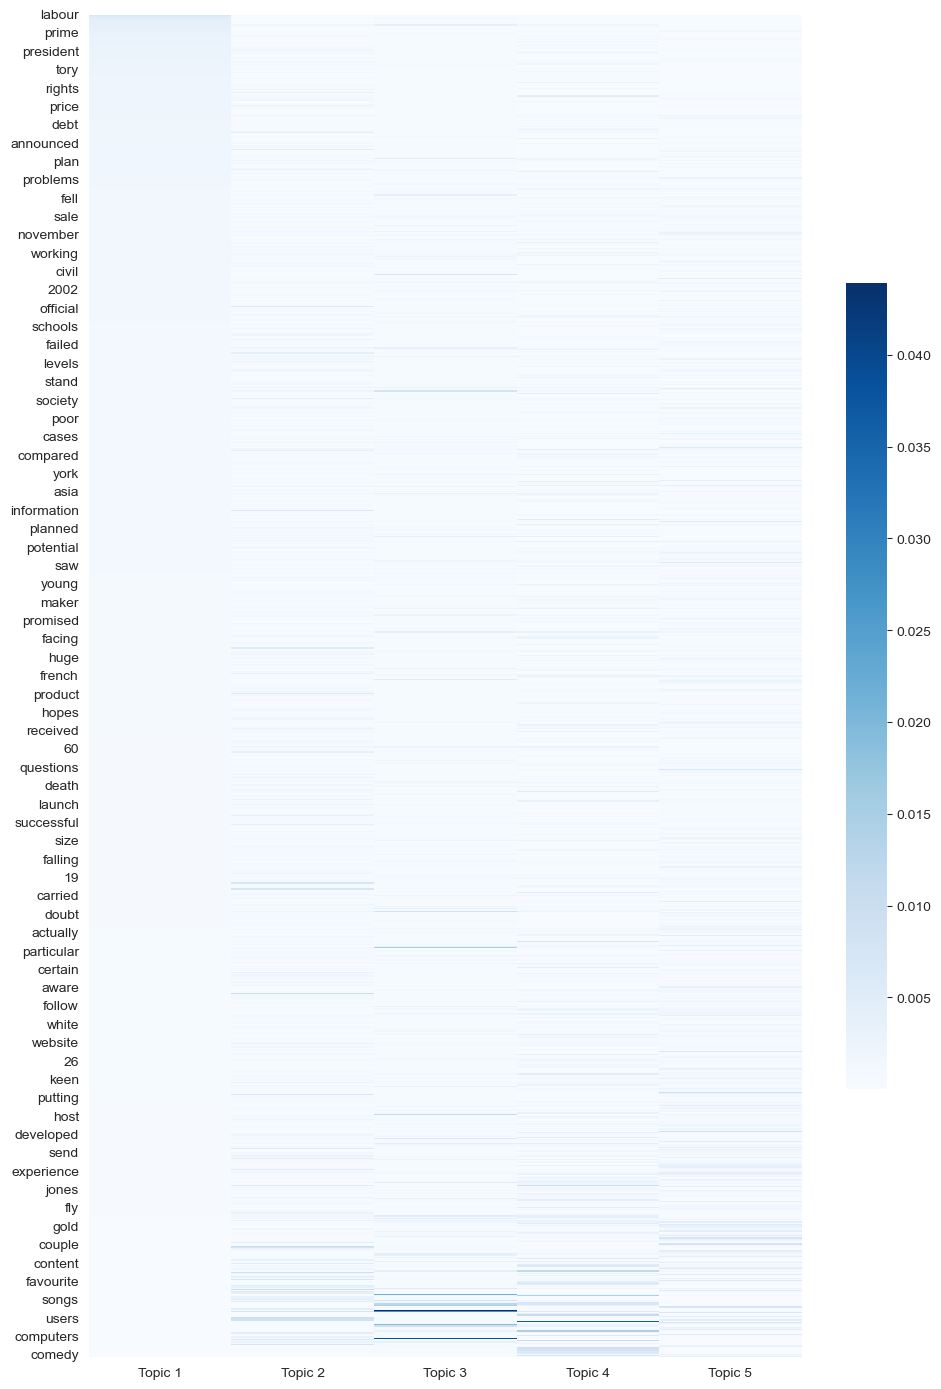

In [24]:
fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(
    topics.sort_values(topic_labels, ascending=False),
    cmap="Blues",
    ax=ax,
    cbar_kws={"shrink": 0.6},
)
fig.tight_layout()

In [25]:
top_words = {}
for topic, words_ in topics.items():
    top_words[topic] = words_.nlargest(10).index.tolist()
pd.DataFrame(top_words)

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
0,labour,mobile,band,film,club
1,election,technology,album,awards,team
2,blair,software,music,award,match
3,party,users,rock,star,cup
4,economy,computer,chart,films,season
5,growth,digital,single,actor,injury
6,bank,games,song,tv,final
7,tax,music,singer,actress,ireland
8,sales,online,tour,oscar,chelsea
9,brown,phone,pop,comedy,coach


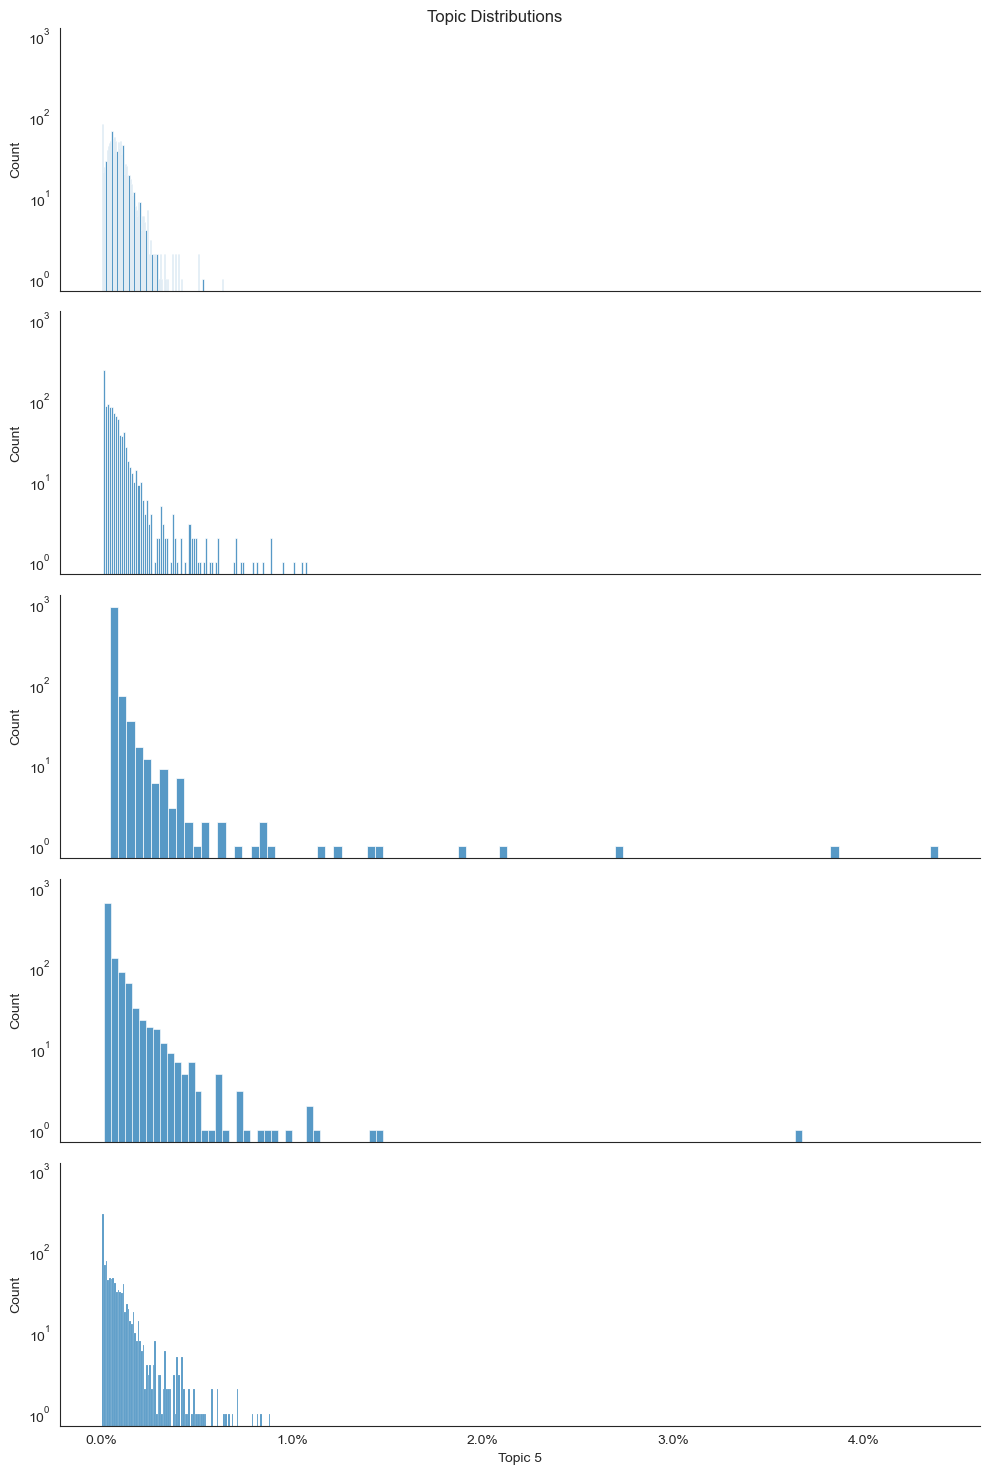

In [27]:
fig, axes = plt.subplots(nrows=5, sharey=True, sharex=True, figsize=(10, 15))
for i, (topic, prob) in enumerate(topics.items()):
    sns.histplot(prob, ax=axes[i], bins=100)
    axes[i].set_yscale("log")
    axes[i].xaxis.set_major_formatter(FuncFormatter(lambda x, _: "{:.1%}".format(x)))
fig.suptitle("Topic Distributions")
sns.despine()
fig.tight_layout()

## Evaluate Fit on Train Set

In [28]:
train_preds = lda_base.transform(train_dtm)
train_preds.shape

(2100, 5)

In [29]:
train_eval = pd.DataFrame(train_preds, columns=topic_labels, index=train_docs.topic)
train_eval.head()

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
topic,,,,,
Sport,0.029879,0.029578,0.029298,0.029675,0.881570
Tech,0.032482,0.858411,0.046849,0.031698,0.030560
Politics,0.915907,0.021213,0.020772,0.020968,0.021141
Sport,0.041267,0.040922,0.040668,0.041008,0.836134
Tech,0.030317,0.793844,0.029833,0.041730,0.104277


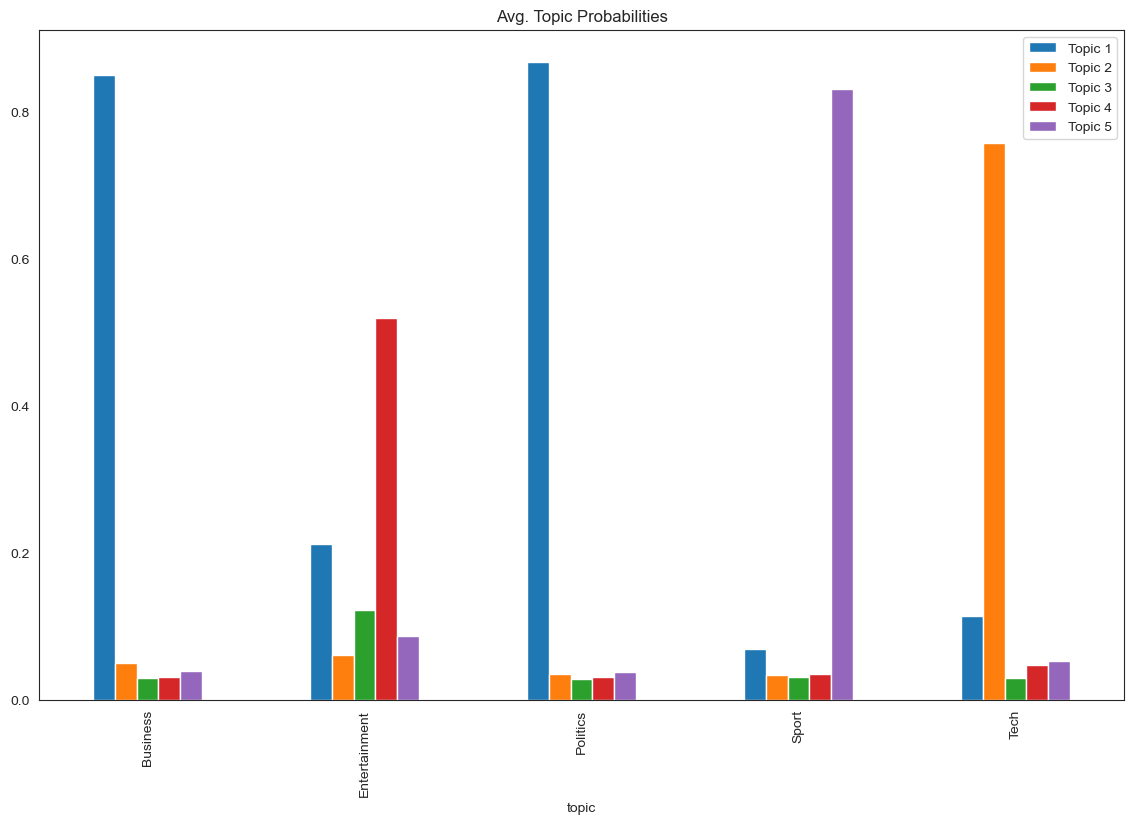

In [30]:
train_eval.groupby(level="topic").mean().plot.bar(title="Avg. Topic Probabilities");

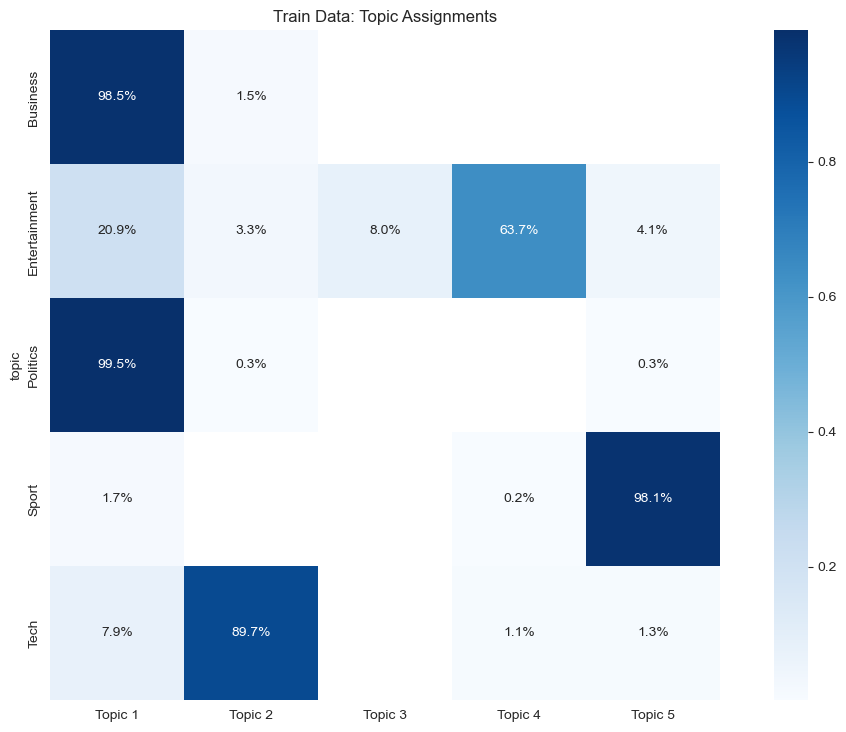

In [31]:
df = train_eval.groupby(level="topic").idxmax(axis=1).reset_index(-1, drop=True)
sns.heatmap(
    df.groupby(level="topic").value_counts(normalize=True).unstack(-1),
    annot=True,
    fmt=".1%",
    cmap="Blues",
    square=True,
)
plt.title("Train Data: Topic Assignments");

## Evaluate Fit on Test Set 

In [32]:
test_preds = lda_base.transform(test_dtm)
test_eval = pd.DataFrame(test_preds, columns=topic_labels, index=test_docs.topic)
test_eval.head()

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
topic,,,,,
Politics,0.899163,0.025169,0.024840,0.025097,0.025730
Sport,0.036421,0.037144,0.035486,0.036795,0.854155
Business,0.836400,0.032078,0.031338,0.031538,0.068647
Business,0.875035,0.031207,0.030648,0.031450,0.031659
Tech,0.316751,0.592904,0.029730,0.030063,0.030552


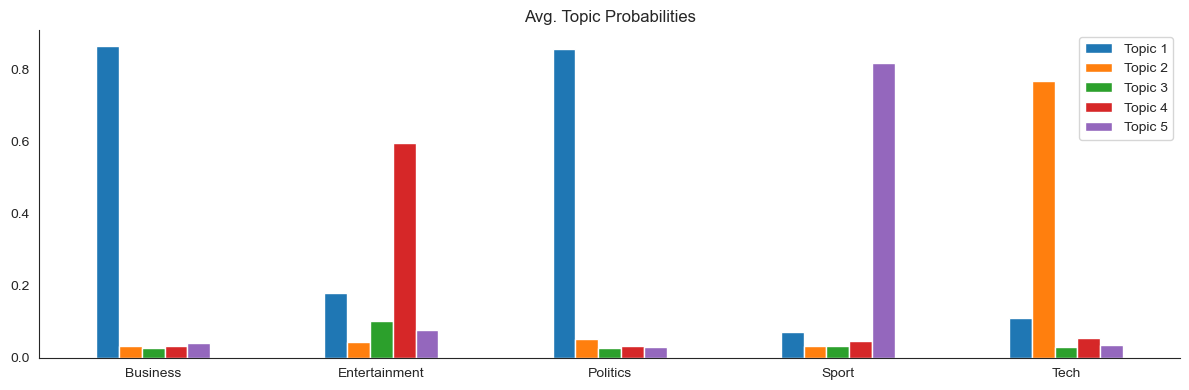

In [33]:
test_eval.groupby(level="topic").mean().plot.bar(
    title="Avg. Topic Probabilities", figsize=(12, 4), rot=0
)
plt.xlabel("")
sns.despine()
plt.tight_layout()

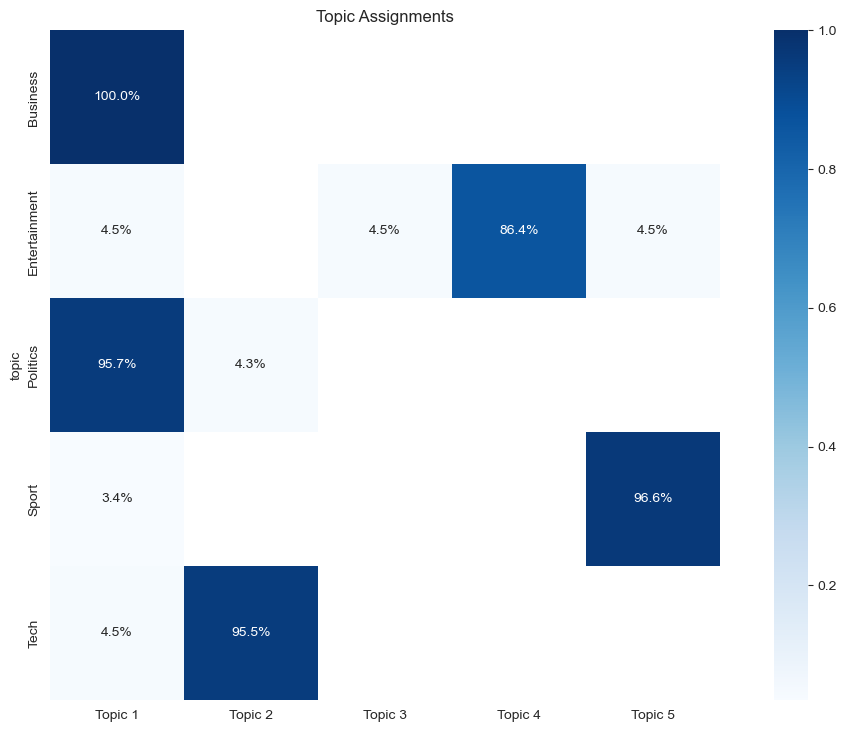

In [34]:
df = test_eval.groupby(level="topic").idxmax(axis=1).reset_index(-1, drop=True)
sns.heatmap(
    df.groupby(level="topic").value_counts(normalize=True).unstack(-1),
    annot=True,
    fmt=".1%",
    cmap="Blues",
    square=True,
)
plt.title("Topic Assignments");

## Retrain until perplexity no longer decreases

In [35]:
lda_opt = LatentDirichletAllocation(
    n_components=5,
    n_jobs=-1,
    max_iter=500,
    learning_method="batch",
    evaluate_every=5,
    verbose=1,
    random_state=42,
)
lda_opt.fit(train_dtm)

iteration: 1 of max_iter: 500
iteration: 2 of max_iter: 500
iteration: 3 of max_iter: 500
iteration: 4 of max_iter: 500
iteration: 5 of max_iter: 500, perplexity: 1911.0374
iteration: 6 of max_iter: 500
iteration: 7 of max_iter: 500
iteration: 8 of max_iter: 500
iteration: 9 of max_iter: 500
iteration: 10 of max_iter: 500, perplexity: 1889.6651
iteration: 11 of max_iter: 500
iteration: 12 of max_iter: 500
iteration: 13 of max_iter: 500
iteration: 14 of max_iter: 500
iteration: 15 of max_iter: 500, perplexity: 1881.1004
iteration: 16 of max_iter: 500
iteration: 17 of max_iter: 500
iteration: 18 of max_iter: 500
iteration: 19 of max_iter: 500
iteration: 20 of max_iter: 500, perplexity: 1874.9061
iteration: 21 of max_iter: 500
iteration: 22 of max_iter: 500
iteration: 23 of max_iter: 500
iteration: 24 of max_iter: 500
iteration: 25 of max_iter: 500, perplexity: 1870.6496
iteration: 26 of max_iter: 500
iteration: 27 of max_iter: 500
iteration: 28 of max_iter: 500
iteration: 29 of max_iter:

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,500
,batch_size,128
,evaluate_every,5
,total_samples,1000000.0
,perp_tol,0.1


In [36]:
joblib.dump(lda_opt, model_path / "lda_opt.pkl")

['results\\bbc\\lda_opt.pkl']

In [37]:
lda_opt = joblib.load(model_path / "lda_opt.pkl")

In [38]:
train_opt_eval = pd.DataFrame(
    data=lda_opt.transform(train_dtm), columns=topic_labels, index=train_docs.topic
)

In [39]:
test_opt_eval = pd.DataFrame(
    data=lda_opt.transform(test_dtm), columns=topic_labels, index=test_docs.topic
)

## Compare Train & Test Topic Assignments 

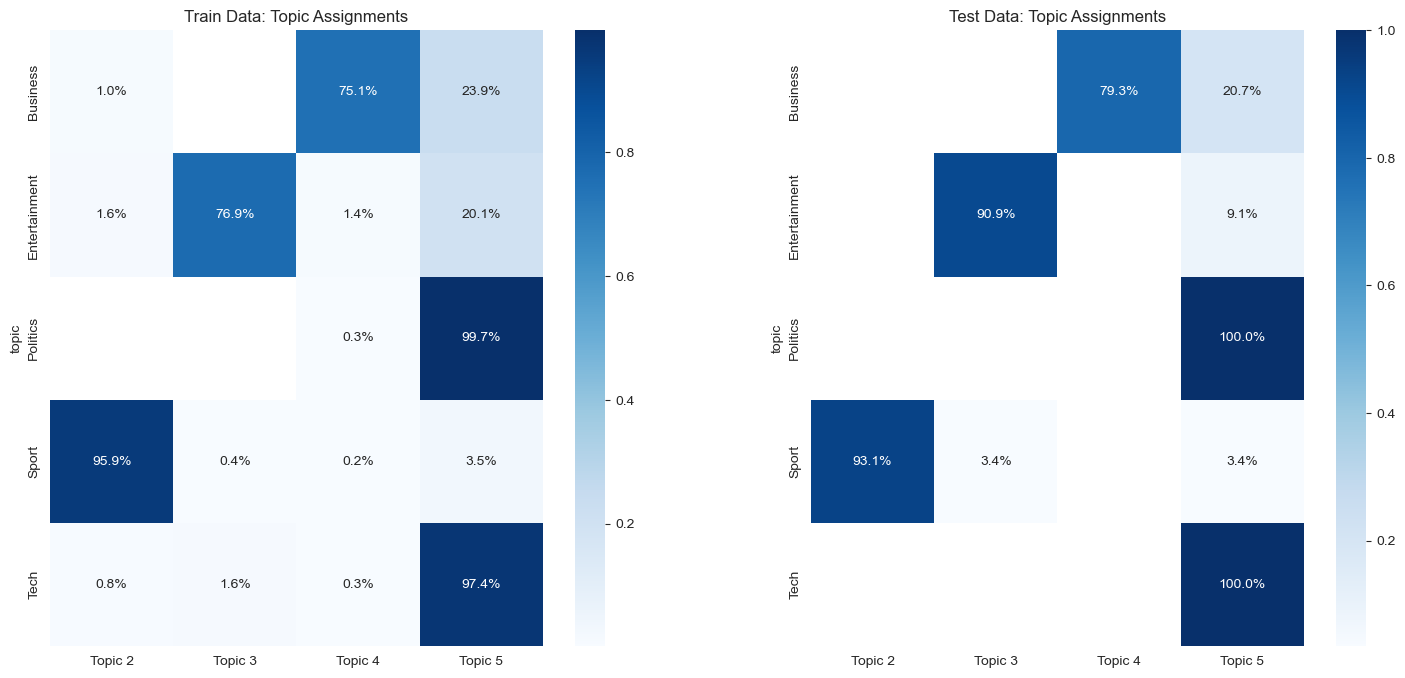

In [40]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 8))
source = ["Train", "Test"]
for i, df in enumerate([train_opt_eval, test_opt_eval]):
    df = df.groupby(level="topic").idxmax(axis=1).reset_index(-1, drop=True)
    sns.heatmap(
        df.groupby(level="topic").value_counts(normalize=True).unstack(-1),
        annot=True,
        fmt=".1%",
        cmap="Blues",
        square=True,
        ax=axes[i],
    )
    axes[i].set_title("{} Data: Topic Assignments".format(source[i]))

## Explore misclassified articles 

In [41]:
test_assignments = test_docs.assign(predicted=test_opt_eval.idxmax(axis=1).values)
test_assignments.head()

,topic,heading,article,predicted
1006,Politics,Kilroy launches 'Veritas' party,Ex-BBC chat show host and East Midlands MEP R...,Topic 5
1358,Sport,Radcliffe eyes hard line on drugs,Paula Radcliffe has called for all athletes f...,Topic 2
71,Business,S Korean consumers spending again,South Korea looks set to sustain its revival ...,Topic 4
372,Business,Quiksilver moves for Rossignol,"Shares of Skis Rossignol, the world's largest...",Topic 4
2151,Tech,Britons fed up with net service,A survey conducted by PC Pro Magazine has rev...,Topic 5


In [43]:
misclassified = test_assignments[
    (test_assignments.topic == "Entertainment")
    & (test_assignments.predicted == "Topic 5")
]
misclassified.heading

521    Neeson in bid to revive theatre
677    Campaigners attack MTV 'sleaze'
Name: heading, dtype: object

In [44]:
misclassified.article.tolist()

[' Hollywood film star Liam Neeson has held a dinner party in New York to promote Belfast\'s Lyric Theatre.  The Ballymena-born actor said that the theatre on Ridgeway Street was in a "very dilapidated condition". Lyric chairman David Johnston has said that rebuilding the theatre, at a cost of Â£8m is the only answer. Mr Neeson said that the idea was to get a bunch of "healthy, wealthy Irish Americans" in one room and ask them to help with fundraising.  The Oscar-nominated actor, whose films include Schindler\'s List, Michael Collins and Star Wars: The Phantom Menace, said: "The Lyric is too important to the cultural and social life of Northern Ireland for this building to crumble and fall apart. "It gave me a start professionally. Mary O\'Malley, the founder of the theatre, gave me my future. "In those days, in the mid-70s, when I was there, we were doing a play every four weeks. "Belfast was not a pretty town to be living in. "There was serious trouble, as you know, but this theatre 

## PyLDAVis

LDAvis helps you interpret LDA results by answer 3 questions:

1. What is the meaning of each topic?
2. How prevalent is each topic?
3. How do topics relate to each other?

Topic visualization facilitates the evaluation of topic quality using human judgment. pyLDAvis is a python port of LDAvis, developed in R and D3.js. We will introduce the key concepts; each LDA implementation notebook contains examples.

pyLDAvis displays the global relationships among topics while also facilitating their semantic evaluation by inspecting the terms most closely associated with each individual topic and, inversely, the topics associated with each term. It also addresses the challenge that terms that are frequent in a corpus tend to dominate the multinomial distribution over words that define a topic. LDAVis introduces the relevance r of term w to topic t to produce a flexible ranking of key terms using a weight parameter 0<=ƛ<=1. 

With $\phi_{wt}$  as the model’s probability estimate of observing the term w for topic t, and   as the marginal probability of w in the corpus:
$$r(w, k | \lambda) = \lambda \log(\phi_{kw}) + (1 − \lambda) \log \frac{\phi_{kw}}{p_w}$$

The first term measures the degree of association of term t with topic w, and the second term measures the lift or saliency, i.e., how much more likely the term is for the topic than in the corpus. 

The tool allows the user to interactively change ƛ to adjust the relevance, which updates the ranking of terms. User studies have found that ƛ=0.6 produces the most plausible results. 

## Refit using all data

In [45]:
vectorizer = CountVectorizer(
    max_df=0.5, min_df=5, stop_words="english", max_features=2000
)
dtm = vectorizer.fit_transform(docs.article)

In [46]:
lda_all = LatentDirichletAllocation(
    n_components=5,
    max_iter=500,
    learning_method="batch",
    evaluate_every=10,
    random_state=42,
    verbose=1,
)
lda_all.fit(dtm)

iteration: 1 of max_iter: 500
iteration: 2 of max_iter: 500
iteration: 3 of max_iter: 500
iteration: 4 of max_iter: 500
iteration: 5 of max_iter: 500
iteration: 6 of max_iter: 500
iteration: 7 of max_iter: 500
iteration: 8 of max_iter: 500
iteration: 9 of max_iter: 500
iteration: 10 of max_iter: 500, perplexity: 1019.9467
iteration: 11 of max_iter: 500
iteration: 12 of max_iter: 500
iteration: 13 of max_iter: 500
iteration: 14 of max_iter: 500
iteration: 15 of max_iter: 500
iteration: 16 of max_iter: 500
iteration: 17 of max_iter: 500
iteration: 18 of max_iter: 500
iteration: 19 of max_iter: 500
iteration: 20 of max_iter: 500, perplexity: 1006.8139
iteration: 21 of max_iter: 500
iteration: 22 of max_iter: 500
iteration: 23 of max_iter: 500
iteration: 24 of max_iter: 500
iteration: 25 of max_iter: 500
iteration: 26 of max_iter: 500
iteration: 27 of max_iter: 500
iteration: 28 of max_iter: 500
iteration: 29 of max_iter: 500
iteration: 30 of max_iter: 500, perplexity: 1003.1615
iteration:

,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,500
,batch_size,128
,evaluate_every,10
,total_samples,1000000.0
,perp_tol,0.1


In [47]:
joblib.dump(lda_all, model_path / "lda_all.pkl")

['results\\bbc\\lda_all.pkl']

In [48]:
lda_all = joblib.load(model_path / "lda_all.pkl")

#### Lambda

- **$\lambda$ = 0**: how probable is a word to appear in a topic - words are ranked on lift P(word | topic) / P(word)
- **$\lambda$ = 1**: how exclusive is a word to a topic -  words are purely ranked on P(word | topic)

The ranking formula is $\lambda * P(\text{word} \vert \text{topic}) + (1 - \lambda) * \text{lift}$

User studies suggest $\lambda = 0.6$ works for most people.

In [52]:
# 1. Get the topic-term distributions
topic_term_dists = lda_all.components_

# 2. Get the document-topic distributions
doc_topic_dists = lda_all.transform(dtm)

# 3. Get the document lengths
doc_lengths = dtm.sum(axis=1).getA1()

# 4. Get the vocabulary
vocab = vectorizer.get_feature_names_out()

# 5. Get the term frequency
term_frequency = dtm.sum(axis=0).getA1()

In [53]:
# Prepare the visualization data
vis_data = prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=vocab,
    term_frequency=term_frequency,
    sort_topics=False,  # Keep original topic order
)

In [56]:
display(vis_data)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.133243 -0.023315       1        1  20.954199
1     -0.202308 -0.116696       2        1  13.011057
2      0.099385  0.080671       3        1  25.501837
3      0.091798 -0.099445       4        1  21.840844
4     -0.122119  0.158784       5        1  18.692064, topic_info=            Term          Freq         Total Category  logprob  loglift
1200          mr  2.091724e+08  2.091724e+08  Default  30.0000  30.0000
1022      labour  5.632557e+07  5.632557e+07  Default  29.0000  29.0000
817   government  8.087825e+07  8.087825e+07  Default  28.0000  28.0000
619     election  4.612898e+07  4.612898e+07  Default  27.0000  27.0000
724         film  3.187662e+07  3.187662e+07  Default  26.0000  26.0000
...          ...           ...           ...      ...      ...      ...
1805       think  1.283930e+07  3.502606e+07   Topic5   5.4834  11.6742
821        great  1.155177e+07  2.070286e+07   Topic5   5.3778  12.0944
1968         won  1.203784e+07  2.795738e+07   Topic5   5.4190  11.8352
1224         new  1.424970e+07  1.132329e+08   Topic5   5.5877  10.6051
808        going  1.179981e+07  3.789757e+07   Topic5   5.3990  11.5110

[353 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
0         1  0.374298      000
0         2  0.073948      000
0         3  0.321887      000
0         4  0.223724      000
0         5  0.006143      000
...     ...       ...      ...
1999      1  0.002279  zealand
1999      2  0.001435  zealand
1999      3  0.002810  zealand
1999      4  0.002361  zealand
1999      5  0.991115  zealand

[1510 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5])

In [57]:
import pyLDAvis.lda_model

In [58]:
pyLDAvis.lda_model.prepare(lda_all, dtm, vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.073450  0.078507       1        1  25.501837
3      0.095719 -0.098360       2        1  21.840844
0      0.141084  0.011426       3        1  20.954199
4     -0.142908  0.141046       4        1  18.692064
1     -0.167345 -0.132619       5        1  13.011057, topic_info=         Term         Freq        Total Category  logprob  loglift
1200       mr  2987.000000  2987.000000  Default  30.0000  30.0000
724      film   838.000000   838.000000  Default  29.0000  29.0000
230      best   960.000000   960.000000  Default  28.0000  28.0000
1022   labour   770.000000   770.000000  Default  27.0000  27.0000
780      game   855.000000   855.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
1081   london   145.604869   454.658340   Topic5  -5.5414   0.9007
1816     time   158.747400  1303.506427   Topic5  -5.4550  -0.0661
1607   series   135.441328   252.071835   Topic5  -5.6138   1.4182
1977    world   147.425268  1173.233921   Topic5  -5.5290  -0.0348
1165  million   135.595694   574.095651   Topic5  -5.6126   0.5963

[353 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
0         1  0.270257      000
0         2  0.219976      000
0         3  0.382130      000
0         4  0.007542      000
0         5  0.121930      000
...     ...       ...      ...
1992      4  0.191599    years
1992      5  0.233952    years
1997      3  0.990918  yugansk
1998      3  0.996584    yukos
1999      4  0.987970  zealand

[672 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 1, 5, 2])

## Topics as WordClouds

In [60]:
topics_prob = lda_all.components_ / lda_all.components_.sum(axis=1).reshape(-1, 1)
topics = pd.DataFrame(
    topics_prob.T, index=vectorizer.get_feature_names_out(), columns=topic_labels
)

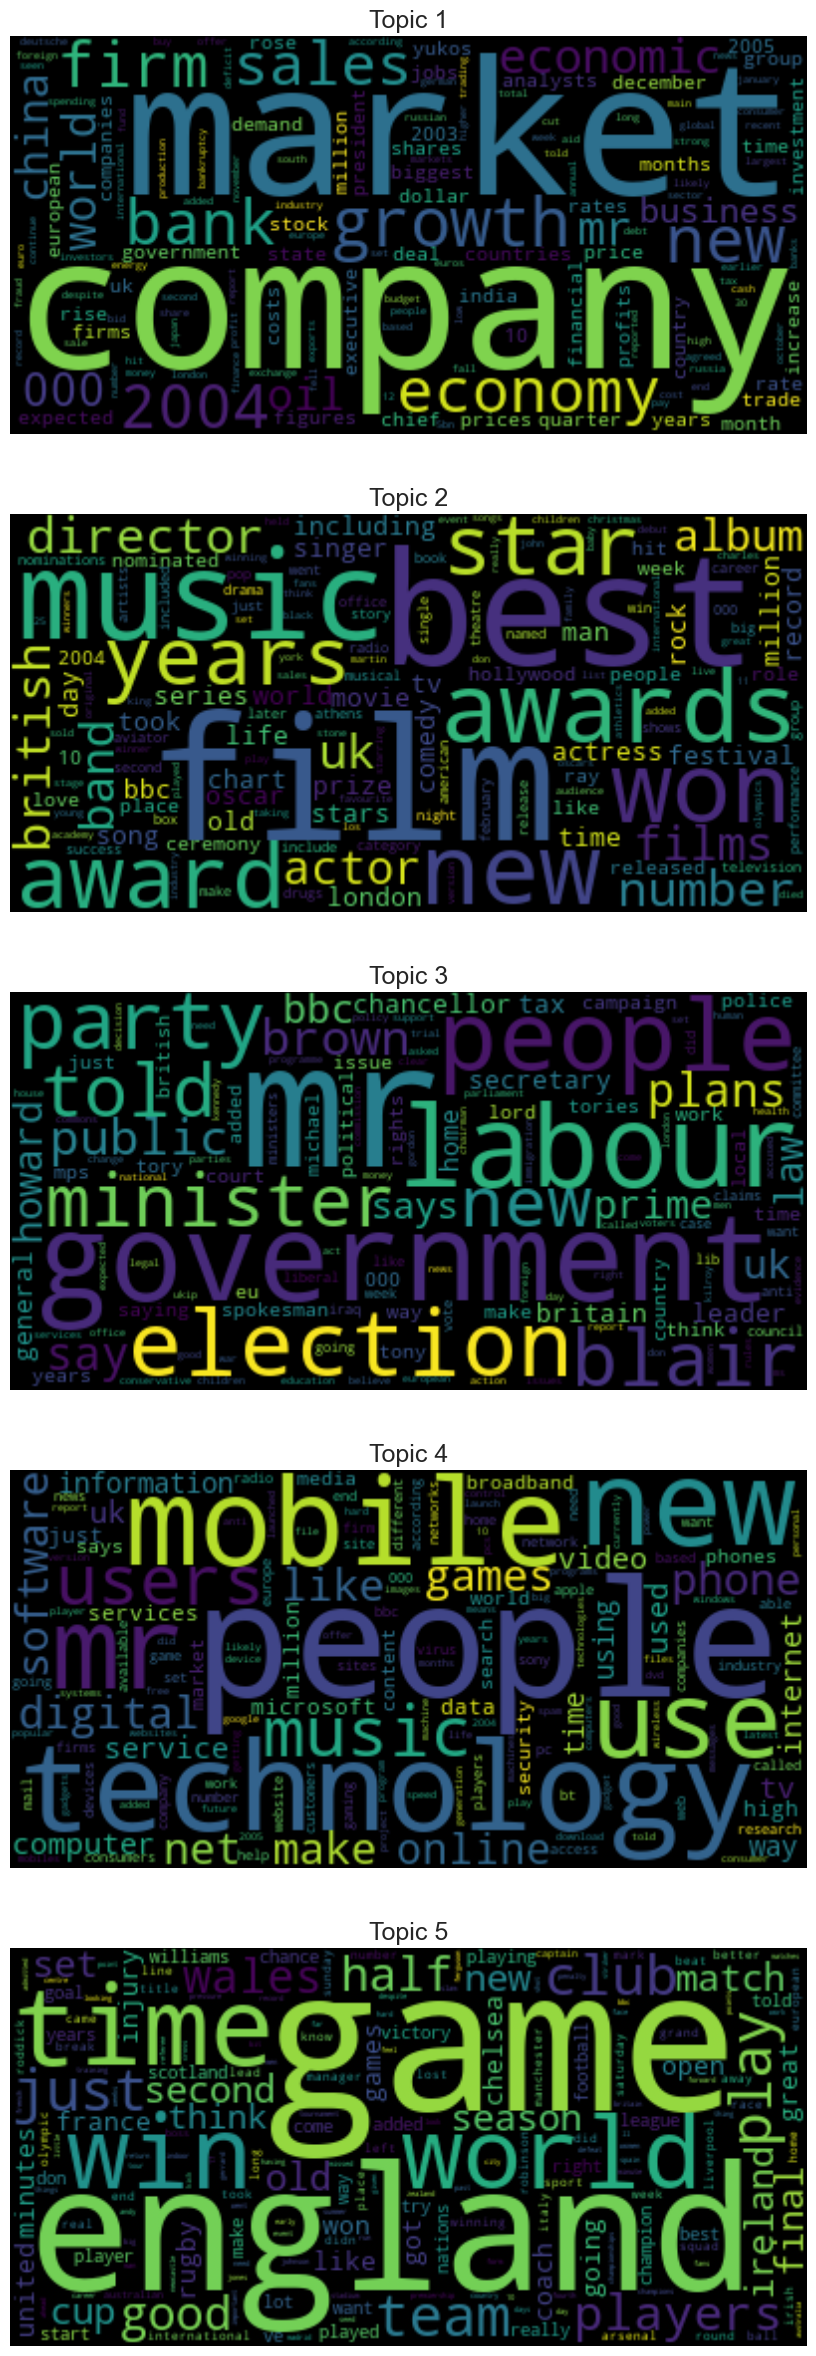

In [61]:
w = WordCloud()
fig, axes = plt.subplots(nrows=5, figsize=(15, 30))
axes = axes.flatten()
for t, (topic, freq) in enumerate(topics.items()):
    w.generate_from_frequencies(freq.to_dict())
    axes[t].imshow(w, interpolation="bilinear")
    axes[t].set_title(topic, fontsize=18)
    axes[t].axis("off")

### Visualize topic-word assocations per document

In [62]:
dtm_ = pd.DataFrame(data=lda_all.transform(dtm), columns=topic_labels, index=docs.topic)

In [63]:
dtm_.head()

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
topic,,,,,
Business,0.757415,0.043291,0.001399,0.196532,0.001363
Business,0.936017,0.001356,0.059912,0.001354,0.001361
Business,0.976877,0.017347,0.001937,0.001917,0.001922
Business,0.994521,0.001373,0.001363,0.001368,0.001375
Business,0.989023,0.002714,0.002762,0.002725,0.002775


In [73]:
color_dict = OrderedDict()
color_dict["Topic 1"] = {"color": "white", "on_color": "on_blue"}
color_dict["Topic 2"] = {"color": "white", "on_color": "on_green"}
color_dict["Topic 3"] = {"color": "white", "on_color": "on_red"}
color_dict["Topic 4"] = {"color": "white", "on_color": "on_magenta"}
color_dict["Topic 5"] = {"color": "white", "on_color": "on_yellow"}

In [69]:
dtm_["article"] = docs.article.values
dtm_["heading"] = docs.heading.values
sample = dtm_[dtm_[topic_labels].gt(0.05).all(1)]
sample

,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,article,heading
topic,,,,,,,
Business,0.630684,0.114709,0.128678,0.065489,0.060440,One of Japan's best-known businessmen was arr...,Japanese mogul arrested for fraud
Entertainment,0.064855,0.319108,0.084398,0.225091,0.306548,Broadcaster Chris Evans has begun selling tho...,Chris Evans back on the market
Entertainment,0.055545,0.168249,0.363690,0.284121,0.128394,Angolan families who are attempting to track ...,TV show unites Angolan families
Entertainment,0.051780,0.742649,0.069040,0.065869,0.070662,"Scottish rock band Franz Ferdinand, who shot ...",Franz Ferdinand's art school lesson
Entertainment,0.229219,0.199995,0.417789,0.070954,0.082044,Proposals to open a museum dedicated to Jimi ...,Row threatens Hendrix museum plan
Entertainment,0.100635,0.634550,0.154238,0.055561,0.055016,"Stan Lee, the man responsible for a string of...",The comic book genius of Stan Lee
Entertainment,0.144835,0.280651,0.232055,0.230626,0.111833,Women in the UK film industry earn less than ...,Women in film 'are earning less'
Tech,0.291468,0.073499,0.108780,0.465605,0.060647,Car-maker Honda's humanoid robot Asimo has ju...,Humanoid robot learns how to run


In [76]:
colored_text = []
for word in sample.iloc[7, 5].split():
    try:
        topic = topics.loc[word.strip().lower()].idxmax()
        colored_text.append(colored(word, **color_dict[topic]))
    except:
        colored_text.append(word)

print(" ".join([colored(k, **v) for k, v in color_dict.items()]))
print("\n", sample.iloc[7, 6], "\n")
text = " ".join(colored_text)
print(text)

Topic 1 Topic 2 Topic 3 Topic 4 Topic 5

 Humanoid robot learns how to run 

Car-maker Honda's humanoid robot Asimo has just got faster and smarter. The Japanese firm is a leader in developing two-legged robots and the new, improved Asimo (Advanced Step in Innovative Mobility) can now run, find his way around obstacles as well as interact with people. Eventually Asimo could find gainful employment in homes and offices. "The aim is to develop a robot that can help people in their daily lives," said a Honda spokesman. To get the robot running for the first time was not an easy process as it involved Asimo making an accurate leap and absorbing the impact of landing without slipping or spinning. The "run" he is now capable of is perhaps not quite up to Olympic star Kelly Holmes' standard. At 3km/h, it is closer to a leisurely jog. Its makers claim that it is almost four times as fast as Sony's Qrio, which became the first robot to run last year. The criteria for running robots is defined b